# <u>Regularization</u>

### Prerequisites:

* <a href="../1.Supervised Learning/1.Regression/4.Ridge,Lasso and Elastic Net Regression/Ridge,Lasso and Elastic Net Regression.ipynb">Check out the notebook on Ridge, Lasso and Elastic Net Regression</a>


    
## Topics

* [1. Weight Decay (WD)](#WD)
* [2. L2 Regularization](#L2)
* [3. Early Stopping](#early)
* [4. Connection Between Early Stopping and L2 / Weight Decay](#connection)
* [5. Big Picture Relationship (Very Important)](#big)


In [1]:
import numpy as np # for random numbers and arrays

# Plotting
import matplotlib.pyplot as plt # for plotting
import plotly.express as px # for plotting
import plotly.graph_objects as go # for plotting

# Create Datasets
from sklearn.datasets import make_regression # create toy data for Regression
from sklearn.datasets import make_classification # create toy data for Classification

# Metrics for Regression
from sklearn.metrics import (
    mean_squared_error, # MSE
    mean_absolute_error, # MAE
)

# Metric for Classification
from sklearn.metrics import (
    accuracy_score, # Accuracy
    brier_score_loss, # Brier Score
    log_loss, # Log Loss
)

from sklearn.preprocessing import StandardScaler # standardize

print("Setup complete")

Setup complete


<a class="anchor" id="WD"></a>

# 1. Weight Decay (WD)

**Weight decay is presented as a regularization technique used during gradient-based optimization, especially in deep learning.**

Idea:

>Instead of only following the gradient that minimizes training loss, we also shrink the weights slightly toward zero at every step.

Start from L2-regularized empirical risk:

$$
\min_\theta \mathcal{R}_\text{reg}(\theta) = \min_\theta \mathcal{R}_\text{emp}(\theta) + \frac{\lambda}{2} \lVert \theta \rVert_2^2
$$

Taking the gradient gives:

$$
\nabla_\theta \mathcal{R}_\text{reg} = \nabla_\theta \mathcal{R}_\text{emp}(\theta) + \lambda \theta
$$

So one GD update becomes:

$$
\begin{align*}
\theta^{[\text{new}]} 
&= \theta^{[\text{old}]} - \alpha(\nabla_\theta \mathcal{R}_\text{emp}(\theta^{[\text{old}]}) + \lambda \theta^{[\text{old}]}) \\

&= \theta^{[\text{old}]} - \alpha\nabla_\theta \mathcal{R}_\text{emp}(\theta^{[\text{old}]}) - \alpha \lambda \theta^{[\text{old}]} \\

&= \theta^{[\text{old}]}(1-\alpha \lambda) - \alpha\nabla_\theta \mathcal{R}_\text{emp}(\theta^{[\text{old}]})

\end{align*}
$$
 
#### Interpretation:

Before taking the normal gradient step, the old weights are multiplied by $1-\alpha \lambda$.

That means:

>Every iteration the parameter vector becomes a little smaller.

Hence the name **Weight decay (WD)**.

Practical intuition:

Without WD:

- optimizer just moves toward lower training loss.

With WD:

- optimizer moves toward lower training loss but is constantly pulled back toward the origin.

So the model is discouraged from using very large weights, which usually reduces overfitting.

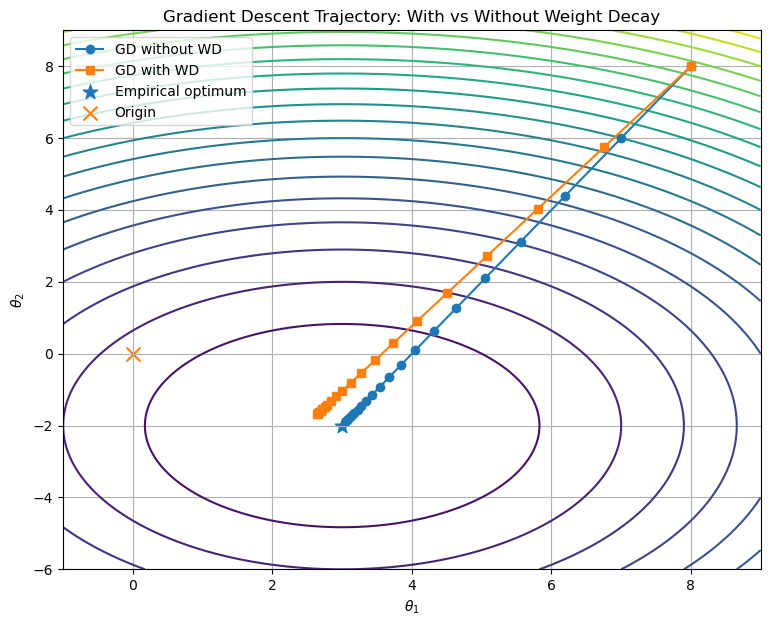

In [ ]:
# Simple empirical risk:
# R_emp(theta) = (theta1-3)^2 + (theta2+2)^2
# empirical optimum is at (3, -2)

def grad_emp(theta):
    theta1, theta2 = theta
    d1 = 2*(theta1 - 3)
    d2 = 2*(theta2 + 2)
    return np.array([d1, d2])

# Gradient descent without WD
def gd_no_wd(theta0, alpha, steps):
    theta = theta0.copy()
    traj = [theta.copy()]
    
    for _ in range(steps):
        theta = theta - alpha * grad_emp(theta)
        traj.append(theta.copy())
        
    return np.array(traj)

# Gradient descent with Weight Decay
def gd_wd(theta0, alpha, lam, steps):
    theta = theta0.copy()
    traj = [theta.copy()]
    
    for _ in range(steps):
        theta = theta*(1 - alpha*lam) - alpha * grad_emp(theta)
        traj.append(theta.copy())
        
    return np.array(traj)

# Parameters
theta0 = np.array([8.0, 8.0]) # start far away
alpha = 0.1
lam = 0.3
steps = 20

traj_no_wd = gd_no_wd(theta0, alpha, steps)
traj_wd    = gd_wd(theta0, alpha, lam, steps)


# Plot contours of empirical risk
x = np.linspace(-1, 9, 200)
y = np.linspace(-6, 9, 200)
X, Y = np.meshgrid(x, y)
Z = (X-3)**2 + (Y+2)**2

plt.figure(figsize=(9,7))
plt.contour(X, Y, Z, levels=20)

# Trajectories
plt.plot(traj_no_wd[:,0], traj_no_wd[:,1], 'o-', label='GD without WD')
plt.plot(traj_wd[:,0], traj_wd[:,1], 's-', label='GD with WD')

# Mark important points
plt.scatter(3, -2, s=120, marker='*', label='Empirical optimum')
plt.scatter(0, 0, s=100, marker='x', label='Origin')

plt.legend()
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title('Gradient Descent Trajectory: With vs Without Weight Decay')
plt.grid(True)
plt.show()

<a class="anchor" id="L2"></a>

# 2. L2 Regularization

L2 regularization is the more general statistical learning view behind weight decay.

It adds a penalty proportional to the squared Euclidean norm of the parameters:

$$
\min_\theta \mathcal{R}_\text{emp}(\theta) + \lambda \lVert \theta \rVert_2^2
$$

This means:
- fit the training data well (small empirical loss),
- but also keep coefficients small (small parameter norm).

### Main effect of L2:

##### Shrinkage, not sparsity

**L2 does not usually force coefficients exactly to zero.**

Instead:

- all parameters are smoothly reduced in magnitude.

So we get:

- a dense model
- but with smaller, more conservative weights.

**This reduces variance and improves generalization**

### Geometric intuition

L2 regularization is equivalent to solving:

$$
\text{minimize training loss subject to } \lVert \theta \rVert_2^2 \leq t
$$

So:

>we are only allowed to choose solutions inside an L2-ball around zero.

The unrestricted optimum may be far away and overfit.

L2 says:

>"find the best fit that still stays reasonably close to zero."

This creates a smooth pull toward simpler models.

<p align="center">
<img src="pics/49.png" width="400"/>
</p>

### Important takeaway:

For plain gradient descent / SGD, L2 regularization and weight decay are mathematically equivalent:

>L2 regularization = weight decay in disguise.

**However:**

**this equivalence only strictly holds for SGD-like optimizers.**

For adaptive optimizers like <u>Adam2</u>, ordinary L2 penalty is not the same as WD.

That is why methods like AdamW were introduced.


<a class="anchor" id="early"></a>

# 3. Early Stopping

Early stopping is introduced as an implicit regularization method.

Instead of adding a penalty term to the objective, we simply:

>stop training before the optimizer fully minimizes training loss.

Why?

Because in many complex models:
- training error keeps decreasing,
- but after some point validation/test error starts increasing.

That means the model starts fitting noise.

So we stop at the point of best validation performance.

#### Procedure:
1. Split training data into:
    - subtrain
    - validation
2. Train iteratively (e.g. SGD)
3. Monitor validation error after small batches of iterations
4. When validation error no longer improves for some patience window:
    - stop training
5. Keep the parameter vector from the best earlier iteration

#### Why this regularizes:

If optimization runs forever, parameters can continue moving into highly complex regions that fit training noise.

Early stopping says:

>Do not let the model become too optimized.

So complexity is controlled by the number of iterations.

Less iterations = simpler model.

<p align="center">
<img src="pics/48.png" width="500"/>
</p>


In [ ]:
#

<a class="anchor" id="connection"></a>

# 4. Connection Between Early Stopping and L2 / Weight Decay

For a simple linear model with:
- squared loss,
- gradient descent,
- initialization at $\theta = 0$,

early stopping has an exact correspondence to L2 regularization.

$$
T_\text{stop} \approx \frac{1}{\alpha \lambda}
$$

equivalently,

$$
\lambda \approx \frac{1}{T_\text{stop} \alpha}
$$

Meaning:

- large stopping time $T_\text{stop}$ = weak regularization = more complex fit
- small stopping time $T_\text{stop}$ = strong regularization = simpler fit

So:

>stopping early acts like indirectly constraining parameter growth, just like L2/WD.

<a class="anchor" id="big"></a>

# 5. Big Picture Relationship (Very Important)

| Method                | How it controls complexity                                     | Explicit or implicit?            |
| --------------------- | -------------------------------------------------------------- | -------------------------------- |
| **L2 regularization** | adds penalty on large weights in objective                     | explicit                         |
| **Weight decay**      | shrinks weights every GD step                                  | explicit optimization form of L2 |
| **Early stopping**    | prevents weights from growing too much by halting optimization | implicit                         |
